In [2]:
import numpy as np
import pandas as pd
import akshare as ak
import baostock as bs

In [3]:
import matplotlib as mpl

In [4]:
%matplotlib notebook
import seaborn as sns
import matplotlib.pyplot as plt

/Users/kongfanxia/opt/miniconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [75]:
lg = bs.login()

login success!


In [9]:
hs300_code_name = pd.read_csv('desktop/stock_data/hs300_code_name.csv')
hs300_code_name.head()

,code,code_name,code_digit
0,sh.600000,浦发银行,600000
1,sh.600009,上海机场,600009
2,sh.600010,包钢股份,600010
3,sh.600011,华能国际,600011
4,sh.600015,华夏银行,600015


In [10]:
rs = bs.query_history_k_data_plus("sh.000300",
        "date,code,open,high,low,close,preclose,volume,amount,pctChg",
        start_date='2026-09-01', end_date='2026-09-30', frequency="d")
data_list = []
while rs.next():
    data_list.append(rs.get_row_data())
result = pd.DataFrame(data_list, columns=rs.fields)
result.head()

,date,code,open,high,low,close,preclose,volume,amount,pctChg
0,2026-09-01,sh.000300,4618.7337,4640.0810,4604.7695,4611.4394,4625.0862,21486958100,535708359906.7000,-0.295060
1,2026-09-02,sh.000300,4581.5140,4583.2709,4534.3894,4547.9559,4611.4394,18699188800,474680402432.2000,-1.376653
2,2026-09-03,sh.000300,4570.9115,4585.9873,4536.9247,4552.5784,4547.9559,18224406000,439940676545.4000,0.101639
3,2026-09-04,sh.000300,4575.3163,4602.1963,4530.7624,4548.0499,4552.5784,19699742800,517509323617.1000,-0.099471
4,2026-09-07,sh.000300,4567.8945,4580.7022,4545.4107,4575.0245,4548.0499,18321847000,535811893130.1000,0.593103


In [11]:
result.to_csv('desktop/stock_data/hs300_data_202609.csv')

In [12]:
data = pd.DataFrame(result, columns=['date', 'close'])
data.head()

,date,close
0,2026-09-01,4611.4394
1,2026-09-02,4547.9559
2,2026-09-03,4552.5784
3,2026-09-04,4548.0499
4,2026-09-07,4575.0245


In [13]:
data['date'] = pd.to_datetime(data['date'])

In [14]:
data['close'] = data['close'].astype(float)

In [15]:
data.dtypes

date     datetime64[ns]
close           float64
dtype: object

In [16]:
data[(data['date']=='2026-09-01')]

,date,close
0,2026-09-01,4611.4394


In [17]:
data[(data['date']=='2026-09-28')]

,date,close
18,2026-09-28,4340.755


<IPython.core.display.Javascript object>


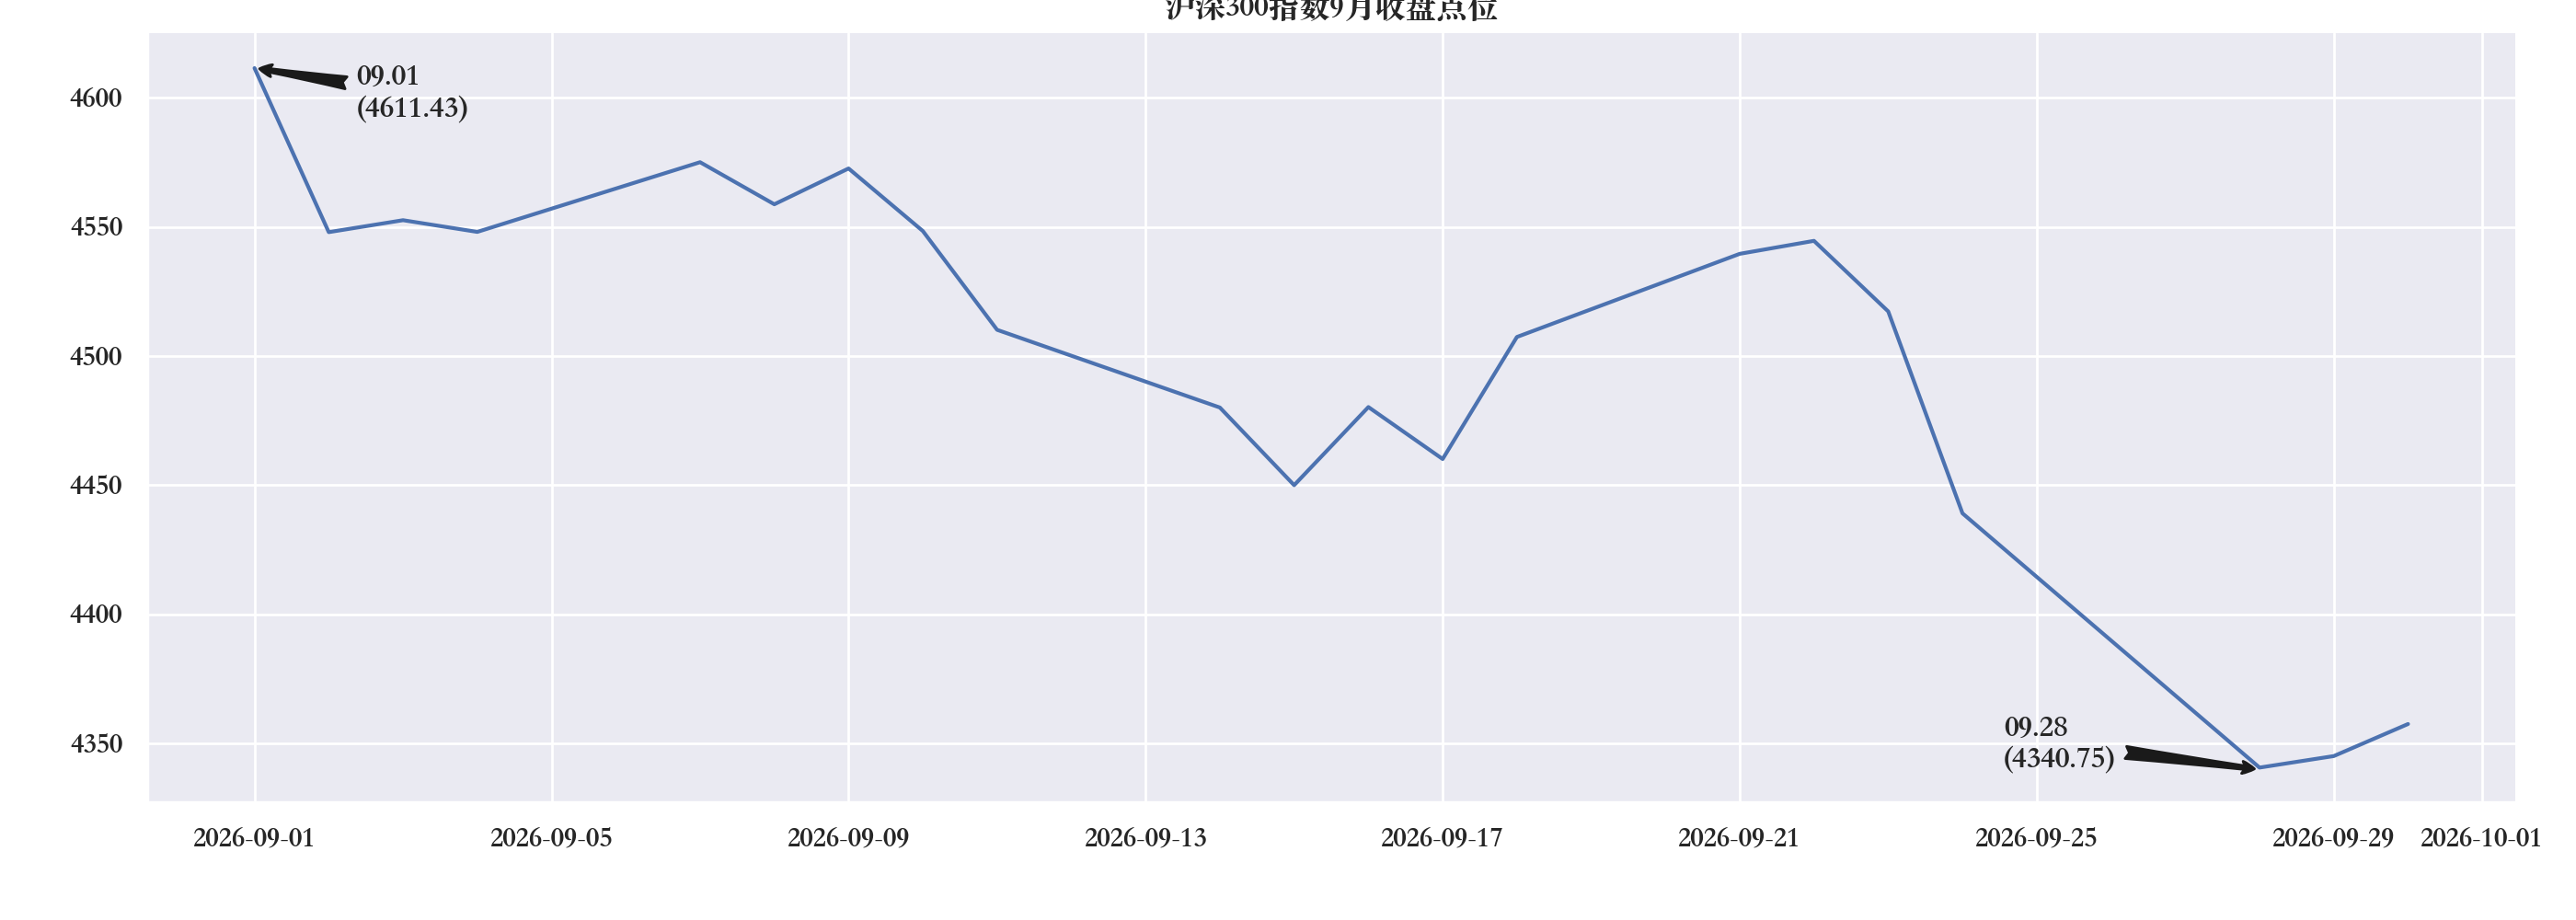

In [31]:
sns.set_theme(font='Songti SC')
plt.rcParams['axes.unicode_minus'] = False
g = sns.relplot(
    data=data, kind="line",
    x="date", y="close",
    aspect=2.8
    )
ax = g.ax

highest_dt = pd.to_datetime('2026-09-01')
ax.annotate('09.01\n(4611.43)', xy=(highest_dt, 4611.5), xycoords='data',
            xytext=(40, -20), textcoords='offset points',
            arrowprops=dict(
                arrowstyle="fancy",
                color='k'))
lowest_dt = pd.to_datetime('2026-09-28')
ax.annotate('09.28\n(4340.75)', xy=(lowest_dt, 4340), xycoords='data',
            xytext=(-100, 0), textcoords='offset points', 
            arrowprops=dict(
                arrowstyle="fancy",
                color='k'))
ax.set(title='沪深300指数9月收盘点位', xlabel=None, ylabel=None)
g;

In [32]:
g.savefig('desktop/stock_data/hs300_202609.svg', bbox_inches='tight')

In [38]:
g.savefig('desktop/stock_data/hs300_202609.png', bbox_inches='tight')

In [37]:
ps = data[(data['date']=='2026-09-01')]['close'].iloc[0]
pe = data[(data['date']=='2026-09-30')]['close'].iloc[0]
ret = (pe - ps) / ps
ret

-0.05504222824656447

In [41]:
peak = data[(data['date']=='2026-09-01')]['close'].iloc[0]
trough = data[(data['date']=='2026-09-28')]['close'].iloc[0]
max_dd = (peak - trough) / peak
max_dd

0.05869846191625116

In [42]:
peak = data[(data['date']=='2026-09-30')]['close'].iloc[0]
trough = data[(data['date']=='2026-09-28')]['close'].iloc[0]
max_rb = (peak - trough) / peak
max_rb

0.003869203237412703

In [43]:
hs300_industry = pd.read_csv('desktop/stock_data/hs300_industry.csv')

In [44]:
hs300_industry.head()

,code,name,sw_industry,sw_code
0,sh.600000,浦发银行,银行,480101
1,sh.600009,上海机场,交通运输,421002
2,sh.600010,包钢股份,钢铁,230402
3,sh.600011,华能国际,公用事业,410101
4,sh.600015,华夏银行,银行,480301


In [48]:
hs300_industry.sw_industry.unique()

array(['银行', '交通运输', '钢铁', '公用事业', '石油石化', '非银金融', '机械设备', '建筑装饰', '房地产',
       '通信', '汽车', '医药生物', '电力设备', '有色金属', '国防军工', '基础化工', '电子', '煤炭',
       '商贸零售', '食品饮料', '计算机', '建筑材料', '家用电器', '传媒', '农林牧渔', '美容护理'],
      dtype=object)

In [51]:
industry_cat = pd.read_csv('desktop/stock_data/industry_cat.csv')
industry_cat.head()

,大类风格,行业
0,周期,石油石化
1,周期,煤炭
2,周期,有色金属
3,周期,钢铁
4,周期,基础化工


In [56]:
industry_cat.columns = ['style', 'sw_industry']
industry_cat.head()

,style,sw_industry
0,周期,石油石化
1,周期,煤炭
2,周期,有色金属
3,周期,钢铁
4,周期,基础化工


In [57]:
hs300_industry = pd.merge(industry_cat, hs300_industry)
hs300_industry.head()

,style,sw_industry,code,name,sw_code
0,周期,石油石化,sh.600028,中国石化,750301
1,周期,石油石化,sh.600346,恒力石化,750301
2,周期,石油石化,sh.600938,中国海油,750101
3,周期,石油石化,sh.601857,中国石油,750301
4,周期,石油石化,sz.000301,东方盛虹,750301


In [5]:
test = ak.stock_zh_a_hist(
    symbol="600028", 
    period='daily', 
    start_date='20260901',
    end_date='20260930',
    adjust='qfq',
    timeout=10)
test.head()

,日期,股票代码,开盘,收盘,最高,最低,成交量,成交额,振幅,涨跌幅,涨跌额,换手率
0,2026-09-01,600028,5.35,5.42,5.45,5.32,2481966,1.367587e+09,2.43,1.12,0.06,0.26
1,2026-09-02,600028,5.46,5.33,5.52,5.33,2385866,1.313226e+09,3.51,-1.66,-0.09,0.25
2,2026-09-03,600028,5.32,5.35,5.43,5.31,1905676,1.042080e+09,2.25,0.38,0.02,0.20
3,2026-09-04,600028,5.35,5.38,5.42,5.33,1675596,9.182996e+08,1.68,0.56,0.03,0.18
4,2026-09-07,600028,5.38,5.27,5.39,5.24,2427155,1.309240e+09,2.79,-2.04,-0.11,0.26


In [6]:
kwargs = {
    'period': 'daily',
    'start_date': '20260901',
    'end_date': '20260930',
    'adjust': 'qfq',
    'timeout': 10
    }

In [7]:
hs300_code_name = pd.read_csv('desktop/stock_data/hs300_code_name.csv')
hs300_code_name.head()

,code,code_name,code_digit
0,sh.600000,浦发银行,600000
1,sh.600009,上海机场,600009
2,sh.600010,包钢股份,600010
3,sh.600011,华能国际,600011
4,sh.600015,华夏银行,600015


In [13]:
hs300_code = hs300_code_name.code_digit
hs300_code = hs300_code.astype(str)
hs300_code.head()

0    600000
1    600009
2    600010
3    600011
4    600015
Name: code_digit, dtype: object

In [18]:
rs = bs.query_history_k_data_plus("sh.600000",
    "date,code,close",
    start_date='2026-09-01', end_date='2026-09-30',
    frequency="d", adjustflag="2")
data_list = []
while rs.next():
    data_list.append(rs.get_row_data())
result = pd.DataFrame(data_list, columns=rs.fields)
result.head()

,date,code,close
0,2026-09-01,sh.600000,9.3500000000
1,2026-09-02,sh.600000,9.2800000000
2,2026-09-03,sh.600000,9.2700000000
3,2026-09-04,sh.600000,9.4300000000
4,2026-09-07,sh.600000,9.2300000000


In [26]:
hs300_code = hs300_code_name.code
hs300_code.head()

0    sh.600000
1    sh.600009
2    sh.600010
3    sh.600011
4    sh.600015
Name: code, dtype: object

In [71]:
diff_list = []
for code in diff:
    print(f'{code} is downloading.')
    rs = bs.query_history_k_data_plus(code,
    "date,code,close",
    start_date='2026-09-01', end_date='2026-09-30',
    frequency="d", adjustflag="2")
    
    data_list = []
    
    while rs.next():
        data_list.append(rs.get_row_data())
    result = pd.DataFrame(data_list, columns=rs.fields)
    diff_list.append(result)

In [43]:
data_all = pd.concat(result_list, ignore_index=True)
data_all.tail()

,date,code,close
4951,2026-09-23,sz.002230,38.7200000000
4952,2026-09-24,sz.002230,38.3200000000
4953,2026-09-28,sz.002230,37.2500000000
4954,2026-09-29,sz.002230,37.2000000000
4955,2026-09-30,sz.002230,37.2200000000


In [62]:
data_code = set(data_all.code.unique())
len(data_code)

236

In [59]:
code_all = set(hs300_code)

In [61]:
diff = code_all - data_code
len(diff)

64

In [76]:
result_list = []
for code in hs300_code:
    rs = bs.query_history_k_data_plus(code,
    "date,code,close",
    start_date='2026-09-01', end_date='2026-09-30',
    frequency="d", adjustflag="2")
    
    data_list = []
    
    while rs.next():
        data_list.append(rs.get_row_data())
    result = pd.DataFrame(data_list, columns=rs.fields)
    result_list.append(result)


In [79]:
data_diff = pd.concat(result_list, ignore_index=True)
data_diff

,date,code,close
0,2026-09-01,sh.600000,9.3500000000
1,2026-09-02,sh.600000,9.2800000000
2,2026-09-03,sh.600000,9.2700000000
3,2026-09-04,sh.600000,9.4300000000
4,2026-09-07,sh.600000,9.2300000000
...,...,...,...
6295,2026-09-23,sz.302132,59.4400000000
6296,2026-09-24,sz.302132,58.1000000000
6297,2026-09-28,sz.302132,58.7300000000
6298,2026-09-29,sz.302132,57.0000000000


In [80]:
len(data_diff.code.unique())

300

In [192]:
data = data_diff

In [83]:
data.isnull().any()

date     False
code     False
close    False
dtype: bool

In [85]:
data.to_csv('desktop/stock_data/hs300_data_202609.csv', index=False)

In [89]:
hs300_industry = pd.read_csv('desktop/stock_data/hs300_industry.csv')
hs300_industry.tail()

,code,name,sw_industry,sw_code
295,sz.301165,锐捷网络,通信,730204
296,sz.301236,软通动力,计算机,710301
297,sz.301269,华大九天,计算机,710401
298,sz.301308,江波龙,电子,270104
299,sz.302132,中航成飞,国防军工,650201


In [193]:
data = pd.merge(data, hs300_industry, on=['code'])
data.head()

,date,code,close,name,sw_industry,sw_code
0,2026-09-01,sh.600000,9.3500000000,浦发银行,银行,480101
1,2026-09-02,sh.600000,9.2800000000,浦发银行,银行,480101
2,2026-09-03,sh.600000,9.2700000000,浦发银行,银行,480101
3,2026-09-04,sh.600000,9.4300000000,浦发银行,银行,480101
4,2026-09-07,sh.600000,9.2300000000,浦发银行,银行,480101


In [194]:
data = data.drop(columns='sw_code')
data.head()

,date,code,close,name,sw_industry
0,2026-09-01,sh.600000,9.3500000000,浦发银行,银行
1,2026-09-02,sh.600000,9.2800000000,浦发银行,银行
2,2026-09-03,sh.600000,9.2700000000,浦发银行,银行
3,2026-09-04,sh.600000,9.4300000000,浦发银行,银行
4,2026-09-07,sh.600000,9.2300000000,浦发银行,银行


In [97]:
industry_cat = pd.read_csv('desktop/stock_data/industry_cat.csv')

,大类风格,行业
0,周期,石油石化
1,周期,煤炭
2,周期,有色金属
3,周期,钢铁
4,周期,基础化工


In [99]:
industry_cat.columns = ['style', 'sw_industry']

In [100]:
industry_cat.head()

,style,sw_industry
0,周期,石油石化
1,周期,煤炭
2,周期,有色金属
3,周期,钢铁
4,周期,基础化工


In [195]:
data = pd.merge(data, industry_cat)
data.tail()

,date,code,close,name,sw_industry,style
6295,2026-09-23,sz.302132,59.4400000000,中航成飞,国防军工,先进制造
6296,2026-09-24,sz.302132,58.1000000000,中航成飞,国防军工,先进制造
6297,2026-09-28,sz.302132,58.7300000000,中航成飞,国防军工,先进制造
6298,2026-09-29,sz.302132,57.0000000000,中航成飞,国防军工,先进制造
6299,2026-09-30,sz.302132,57.7600000000,中航成飞,国防军工,先进制造


In [196]:
data.isnull().any()

date           False
code           False
close          False
name           False
sw_industry    False
style          False
dtype: bool

In [124]:
weight = ak.index_stock_cons_weight_csindex(symbol='000300')
weight.head()

,日期,指数代码,指数名称,指数英文名称,成分券代码,成分券名称,成分券英文名称,交易所,交易所英文名称,权重
0,2026-08-31,000300,沪深300,CSI 300,000001,平安银行,"Ping An Bank Co., Ltd.",深圳证券交易所,Shenzhen Stock Exchange,0.433
1,2026-08-31,000300,沪深300,CSI 300,000002,万科A,China Vanke Co Ltd,深圳证券交易所,Shenzhen Stock Exchange,0.081
2,2026-08-31,000300,沪深300,CSI 300,000063,中兴通讯,ZTE Corporation,深圳证券交易所,Shenzhen Stock Exchange,0.419
3,2026-08-31,000300,沪深300,CSI 300,000100,TCL科技,TCL Technology Group Corporation,深圳证券交易所,Shenzhen Stock Exchange,0.403
4,2026-08-31,000300,沪深300,CSI 300,000157,中联重科,Zoomlion Heavy Industry Science & Technology C...,深圳证券交易所,Shenzhen Stock Exchange,0.126


In [125]:
weight = weight[['成分券代码', '权重']]

In [126]:
weight.columns = ['code_digit', 'weight']

In [156]:
weight.tail()

,code_digit,weight
295,688396,0.124
296,688472,0.050
297,688506,0.084
298,688521,0.321
299,688981,0.998


In [112]:
hs300_code_name.head()

,code,code_name,code_digit
0,sh.600000,浦发银行,600000
1,sh.600009,上海机场,600009
2,sh.600010,包钢股份,600010
3,sh.600011,华能国际,600011
4,sh.600015,华夏银行,600015


In [183]:
hs300_code_name.code_digit = hs300_code_name.code.str.split(".").str[1]
hs300_code_name.tail()

,code,code_name,code_digit
295,sz.301165,锐捷网络,301165
296,sz.301236,软通动力,301236
297,sz.301269,华大九天,301269
298,sz.301308,江波龙,301308
299,sz.302132,中航成飞,302132


In [164]:
weight.dtypes

code_digit     object
weight        float64
dtype: object

In [184]:
hs300_code_name.dtypes

code          object
code_name     object
code_digit    object
dtype: object

In [173]:
hs300_code_name.code_digit = hs300_code_name.code_digit.astype(str)

In [177]:
hs300_code_name.code_digit

0      600000
1      600009
2      600010
3      600011
4      600015
        ...  
295    301165
296    301236
297    301269
298    301308
299    302132
Name: code_digit, Length: 300, dtype: object

In [174]:
weight.code_digit = weight.code_digit.astype(str)

In [176]:
weight.code_digit

0      000001
1      000002
2      000063
3      000100
4      000157
        ...  
295    688396
296    688472
297    688506
298    688521
299    688981
Name: code_digit, Length: 300, dtype: object

In [185]:
s = hs300_code_name.code_digit
# 找出s里面，不在weight.code_digit里的元素
mask = ~s.isin(weight.code_digit)
missing_series = s[mask]
missing_series


Series([], Name: code_digit, dtype: object)

In [186]:
df = pd.merge(hs300_code_name, weight)
df

,code,code_name,code_digit,weight
0,sh.600000,浦发银行,600000,0.465
1,sh.600009,上海机场,600009,0.110
2,sh.600010,包钢股份,600010,0.194
3,sh.600011,华能国际,600011,0.112
4,sh.600015,华夏银行,600015,0.151
...,...,...,...,...
295,sz.301165,锐捷网络,301165,0.065
296,sz.301236,软通动力,301236,0.089
297,sz.301269,华大九天,301269,0.083
298,sz.301308,江波龙,301308,0.369


In [187]:
hs300_code_name.to_csv('desktop/stock_data/hs300_code_name.csv')

In [198]:
data.head()

,date,code,close,name,sw_industry,style
0,2026-09-01,sh.600000,9.3500000000,浦发银行,银行,金融地产
1,2026-09-02,sh.600000,9.2800000000,浦发银行,银行,金融地产
2,2026-09-03,sh.600000,9.2700000000,浦发银行,银行,金融地产
3,2026-09-04,sh.600000,9.4300000000,浦发银行,银行,金融地产
4,2026-09-07,sh.600000,9.2300000000,浦发银行,银行,金融地产


In [189]:
hs300_weight = df.drop(columns = ['code_name', 'code_digit'])
hs300_weight.head()

,code,weight
0,sh.600000,0.465
1,sh.600009,0.110
2,sh.600010,0.194
3,sh.600011,0.112
4,sh.600015,0.151


In [199]:
data = pd.merge(data, hs300_weight)

In [201]:
data.tail()

,date,code,close,name,sw_industry,style,weight
6295,2026-09-23,sz.302132,59.4400000000,中航成飞,国防军工,先进制造,0.067
6296,2026-09-24,sz.302132,58.1000000000,中航成飞,国防军工,先进制造,0.067
6297,2026-09-28,sz.302132,58.7300000000,中航成飞,国防军工,先进制造,0.067
6298,2026-09-29,sz.302132,57.0000000000,中航成飞,国防军工,先进制造,0.067
6299,2026-09-30,sz.302132,57.7600000000,中航成飞,国防军工,先进制造,0.067


In [239]:
data_s_e = data[(data['date'].isin(['2026-09-01', '2026-09-30']))]

In [240]:
data_s_e.head()

,date,code,close,name,sw_industry,style,weight
0,2026-09-01,sh.600000,9.3500000000,浦发银行,银行,金融地产,0.465
20,2026-09-30,sh.600000,9.4800000000,浦发银行,银行,金融地产,0.465
21,2026-09-01,sh.600009,23.1926784800,上海机场,交通运输,周期,0.110
41,2026-09-30,sh.600009,22.5800000000,上海机场,交通运输,周期,0.110
42,2026-09-01,sh.600010,2.2700000000,包钢股份,钢铁,周期,0.194


In [206]:
len(data_s_e.code.unique())

300

In [207]:
hs300_code_name.head()

,code,code_name,code_digit
0,sh.600000,浦发银行,600000
1,sh.600009,上海机场,600009
2,sh.600010,包钢股份,600010
3,sh.600011,华能国际,600011
4,sh.600015,华夏银行,600015


In [231]:
pd.to_numeric(data_s_e.loc['sh.600000', '2026-09-01'].close)

9.35

In [248]:
close = data_s_e.pivot(index='code', columns='date', values='close')

In [255]:
close = close.astype(float)

In [256]:
close.columns = ['start', 'end']
close.head()

,start,end
code,,
sh.600000,9.350000,9.48
sh.600009,23.192678,22.58
sh.600010,2.270000,2.09
sh.600011,6.800000,7.04
sh.600015,6.320000,6.27


In [258]:
close['ret'] = (close.end - close.start) / close.start
close.head()

,start,end,ret
code,,,
sh.600000,9.350000,9.48,0.013904
sh.600009,23.192678,22.58,-0.026417
sh.600010,2.270000,2.09,-0.079295
sh.600011,6.800000,7.04,0.035294
sh.600015,6.320000,6.27,-0.007911


In [259]:
ret = close.drop(columns=['start', 'end'])
ret.head()

,ret
code,
sh.600000,0.013904
sh.600009,-0.026417
sh.600010,-0.079295
sh.600011,0.035294
sh.600015,-0.007911


In [260]:
len(ret)

300

In [263]:
ret.isnull().any()

ret    False
dtype: bool

In [264]:
ret = ret.reset_index()

In [265]:
ret.head()

,code,ret
0,sh.600000,0.013904
1,sh.600009,-0.026417
2,sh.600010,-0.079295
3,sh.600011,0.035294
4,sh.600015,-0.007911


In [267]:
data.tail()

,date,code,close,name,sw_industry,style,weight
6295,2026-09-23,sz.302132,59.4400000000,中航成飞,国防军工,先进制造,0.067
6296,2026-09-24,sz.302132,58.1000000000,中航成飞,国防军工,先进制造,0.067
6297,2026-09-28,sz.302132,58.7300000000,中航成飞,国防军工,先进制造,0.067
6298,2026-09-29,sz.302132,57.0000000000,中航成飞,国防军工,先进制造,0.067
6299,2026-09-30,sz.302132,57.7600000000,中航成飞,国防军工,先进制造,0.067


In [272]:
data_style = data[['code', 'name', 'sw_industry', 'style', 'weight']].drop_duplicates()

In [275]:
data_style = data_style.reset_index(drop=True)

In [276]:
ret_data = pd.merge(data_style, ret)
ret_data

,code,name,sw_industry,style,weight,ret
0,sh.600000,浦发银行,银行,金融地产,0.465,0.013904
1,sh.600009,上海机场,交通运输,周期,0.110,-0.026417
2,sh.600010,包钢股份,钢铁,周期,0.194,-0.079295
3,sh.600011,华能国际,公用事业,周期,0.112,0.035294
4,sh.600015,华夏银行,银行,金融地产,0.151,-0.007911
...,...,...,...,...,...,...
295,sz.301165,锐捷网络,通信,科技（TMT）,0.065,-0.156069
296,sz.301236,软通动力,计算机,科技（TMT）,0.089,-0.078231
297,sz.301269,华大九天,计算机,科技（TMT）,0.083,-0.132671
298,sz.301308,江波龙,电子,科技（TMT）,0.369,-0.182160


In [277]:
ret_data.to_csv('desktop/stock_data/hs300_ret_202609.csv')

In [278]:
ret_data['ret_weight'] = ret_data.weight * ret_data.ret
ret_data

,code,name,sw_industry,style,weight,ret,ret_weight
0,sh.600000,浦发银行,银行,金融地产,0.465,0.013904,0.006465
1,sh.600009,上海机场,交通运输,周期,0.110,-0.026417,-0.002906
2,sh.600010,包钢股份,钢铁,周期,0.194,-0.079295,-0.015383
3,sh.600011,华能国际,公用事业,周期,0.112,0.035294,0.003953
4,sh.600015,华夏银行,银行,金融地产,0.151,-0.007911,-0.001195
...,...,...,...,...,...,...,...
295,sz.301165,锐捷网络,通信,科技（TMT）,0.065,-0.156069,-0.010145
296,sz.301236,软通动力,计算机,科技（TMT）,0.089,-0.078231,-0.006963
297,sz.301269,华大九天,计算机,科技（TMT）,0.083,-0.132671,-0.011012
298,sz.301308,江波龙,电子,科技（TMT）,0.369,-0.182160,-0.067217


In [293]:
style_weight = ret_data.groupby('style')['weight'].sum()
style_weight

style
先进制造       15.269
医药医疗        4.103
周期         18.751
消费          9.629
科技（TMT）    32.956
金融地产       19.292
Name: weight, dtype: float64

In [294]:
style_weight = pd.DataFrame(style_weight)

In [298]:
style_weight = style_weight.reset_index()

In [300]:
ret_data = pd.read_csv('desktop/stock_data/hs300_ret_202609.csv').drop(columns=['Unnamed: 0'])

In [301]:

ret_data

,code,name,sw_industry,style,weight,ret
0,sh.600000,浦发银行,银行,金融地产,0.465,0.013904
1,sh.600009,上海机场,交通运输,周期,0.110,-0.026417
2,sh.600010,包钢股份,钢铁,周期,0.194,-0.079295
3,sh.600011,华能国际,公用事业,周期,0.112,0.035294
4,sh.600015,华夏银行,银行,金融地产,0.151,-0.007911
...,...,...,...,...,...,...
295,sz.301165,锐捷网络,通信,科技（TMT）,0.065,-0.156069
296,sz.301236,软通动力,计算机,科技（TMT）,0.089,-0.078231
297,sz.301269,华大九天,计算机,科技（TMT）,0.083,-0.132671
298,sz.301308,江波龙,电子,科技（TMT）,0.369,-0.182160


In [304]:
style_weight = style_weight.rename(columns = {'weight': 'style_weight'})

In [305]:
ret_data = pd.merge(style_weight, ret_data)
ret_data

,style,style_weight,code,name,sw_industry,weight,ret
0,先进制造,15.269,sh.600031,三一重工,机械设备,0.452,-0.135015
1,先进制造,15.269,sh.600066,宇通客车,汽车,0.151,-0.125082
2,先进制造,15.269,sh.600089,特变电工,电力设备,0.368,-0.089858
3,先进制造,15.269,sh.600104,上汽集团,汽车,0.182,0.037178
4,先进制造,15.269,sh.600118,中国卫星,国防军工,0.136,-0.073881
...,...,...,...,...,...,...,...
295,金融地产,19.292,sz.000617,中油资本,非银金融,0.070,-0.117093
296,金融地产,19.292,sz.000776,广发证券,非银金融,0.245,-0.092237
297,金融地产,19.292,sz.001979,招商蛇口,房地产,0.090,0.175194
298,金融地产,19.292,sz.002142,宁波银行,银行,0.429,0.032945


In [323]:
def ret_by_weight(x):
    x = x.copy()
    style_weight = x['weight'].sum()
    sector_ret = (x['weight'] * x['ret']).sum()
    x['ret_by_weight'] = sector_ret / style_weight
    
    return x

In [336]:
ret_by_weight = ret_data.groupby('style').apply(ret_by_weight, include_groups=False)

In [345]:
ret_by_weight = ret_by_weight.reset_index().drop(columns='level_1')

In [346]:
ret_by_weight

,style,style_weight,code,name,sw_industry,weight,ret,ret_by_weight
0,先进制造,15.269,sh.600031,三一重工,机械设备,0.452,-0.135015,-0.091811
1,先进制造,15.269,sh.600066,宇通客车,汽车,0.151,-0.125082,-0.091811
2,先进制造,15.269,sh.600089,特变电工,电力设备,0.368,-0.089858,-0.091811
3,先进制造,15.269,sh.600104,上汽集团,汽车,0.182,0.037178,-0.091811
4,先进制造,15.269,sh.600118,中国卫星,国防军工,0.136,-0.073881,-0.091811
...,...,...,...,...,...,...,...,...
295,金融地产,19.292,sz.000617,中油资本,非银金融,0.070,-0.117093,-0.016879
296,金融地产,19.292,sz.000776,广发证券,非银金融,0.245,-0.092237,-0.016879
297,金融地产,19.292,sz.001979,招商蛇口,房地产,0.090,0.175194,-0.016879
298,金融地产,19.292,sz.002142,宁波银行,银行,0.429,0.032945,-0.016879


In [350]:
ret_style = ret_by_weight[['style', 'ret_by_weight']].drop_duplicates().reset_index(drop=True)
ret_style

,style,ret_by_weight
0,先进制造,-0.091811
1,医药医疗,0.029803
2,周期,-0.061071
3,消费,-0.034869
4,科技（TMT）,-0.068603
5,金融地产,-0.016879


In [351]:
ret_by_weight.to_csv('desktop/stock_data/hs300_ret_by_weight_202609.csv')

In [352]:
ret_style.to_csv('desktop/stock_data/hs300_ret_style_202609.csv')

In [369]:
ret_style['color_tag'] = ret_style['ret_by_weight'].apply(lambda x: '正' if x>0 else '负')
ret_style.head()

,style,ret_by_weight,color_tag
0,先进制造,-0.091811,负
1,医药医疗,0.029803,正
2,周期,-0.061071,负
3,消费,-0.034869,负
4,科技（TMT）,-0.068603,负


In [407]:
add_hs300 = pd.DataFrame({
    'style':['沪深300'],
    'ret_by_weight':[-0.055042],
    'color_tag':['负']})
add_hs300

,style,ret_by_weight,color_tag
0,沪深300,-0.055042,负


In [410]:
ret_style = pd.concat([ret_style, add_hs300])

In [420]:
ret_style[(ret_style['style']=='沪深300')]['ret_by_weight'].iloc[0]

-0.055042

<IPython.core.display.Javascript object>


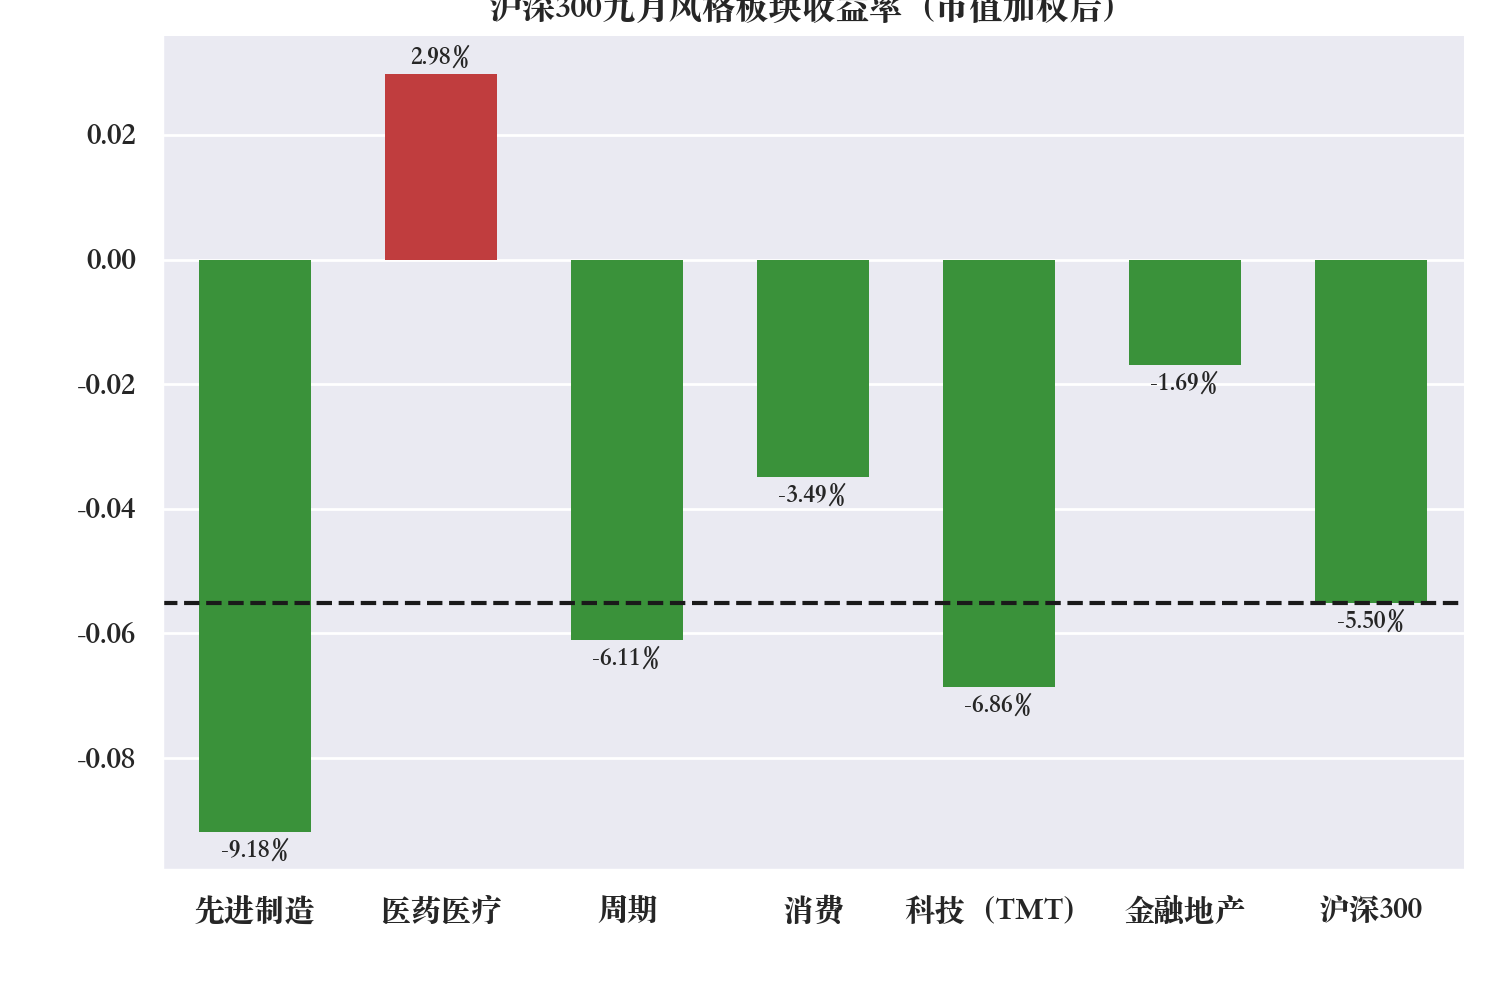

In [482]:
sns.set_theme(font='Songti SC')
plt.rcParams['axes.unicode_minus'] = False
g = sns.catplot(data=ret_style, 
            kind='bar', 
            x='style', 
            y='ret_by_weight',
            hue='color_tag',
            palette={'正':'#d62728', '负':'#2ca02c'},
            edgecolor="none",
            width=0.6,
            aspect=1.5,
            legend=None
           )
ax = g.ax
ax.set(xlabel=None, ylabel=None, title='沪深300九月风格板块收益率（市值加权后）')
for bar in ax.patches:
    height = bar.get_height()
    # 位置：x居中，y在柱子顶端
    x_pos = bar.get_x() + bar.get_width() / 2
    # 正负值微调文字偏移方向，防止文字贴柱子
    yshift = 2 if height > 0 else -2
    ax.annotate(
        f'{height:.2%}',
        xy=(x_pos, height),
        xytext=(0, yshift), 
        textcoords="offset points",
        ha='center', va='bottom' if height>0 else 'top',
        fontsize=9
    )
y_hline = ret_style[(ret_style['style']=='沪深300')]['ret_by_weight'].iloc[0] 
plt.axhline(y_hline, color='k', linestyle="--");

In [483]:
g.savefig('desktop/stock_data/style_ret.svg', bbox_inches='tight')

In [423]:
ret_by_weight.head()


,style,style_weight,code,name,sw_industry,weight,ret,ret_by_weight
0,先进制造,15.269,sh.600031,三一重工,机械设备,0.452,-0.135015,-0.091811
1,先进制造,15.269,sh.600066,宇通客车,汽车,0.151,-0.125082,-0.091811
2,先进制造,15.269,sh.600089,特变电工,电力设备,0.368,-0.089858,-0.091811
3,先进制造,15.269,sh.600104,上汽集团,汽车,0.182,0.037178,-0.091811
4,先进制造,15.269,sh.600118,中国卫星,国防军工,0.136,-0.073881,-0.091811


In [506]:
data = ret_by_weight.drop(columns='ret_by_weight')
data.head()

,style,style_weight,code,name,sw_industry,weight,ret
0,先进制造,15.269,sh.600031,三一重工,机械设备,0.452,-0.135015
1,先进制造,15.269,sh.600066,宇通客车,汽车,0.151,-0.125082
2,先进制造,15.269,sh.600089,特变电工,电力设备,0.368,-0.089858
3,先进制造,15.269,sh.600104,上汽集团,汽车,0.182,0.037178
4,先进制造,15.269,sh.600118,中国卫星,国防军工,0.136,-0.073881


In [507]:
data.tail()

,style,style_weight,code,name,sw_industry,weight,ret
295,金融地产,19.292,sz.000617,中油资本,非银金融,0.070,-0.117093
296,金融地产,19.292,sz.000776,广发证券,非银金融,0.245,-0.092237
297,金融地产,19.292,sz.001979,招商蛇口,房地产,0.090,0.175194
298,金融地产,19.292,sz.002142,宁波银行,银行,0.429,0.032945
299,金融地产,19.292,sz.002736,国信证券,非银金融,0.120,-0.051307


In [426]:
data.weight.sum()

100.0

In [428]:
data['style'].unique()

array(['先进制造', '医药医疗', '周期', '消费', '科技（TMT）', '金融地产'], dtype=object)

In [508]:
data

,style,style_weight,code,name,sw_industry,weight,ret
0,先进制造,15.269,sh.600031,三一重工,机械设备,0.452,-0.135015
1,先进制造,15.269,sh.600066,宇通客车,汽车,0.151,-0.125082
2,先进制造,15.269,sh.600089,特变电工,电力设备,0.368,-0.089858
3,先进制造,15.269,sh.600104,上汽集团,汽车,0.182,0.037178
4,先进制造,15.269,sh.600118,中国卫星,国防军工,0.136,-0.073881
...,...,...,...,...,...,...,...
295,金融地产,19.292,sz.000617,中油资本,非银金融,0.070,-0.117093
296,金融地产,19.292,sz.000776,广发证券,非银金融,0.245,-0.092237
297,金融地产,19.292,sz.001979,招商蛇口,房地产,0.090,0.175194
298,金融地产,19.292,sz.002142,宁波银行,银行,0.429,0.032945


In [433]:
data_manu.dtypes

style            object
style_weight    float64
code             object
name             object
sw_industry      object
weight          float64
ret             float64
dtype: object

In [509]:
data_list = []
for style in data['style'].unique():
    data_i = data[(data['style']==style)].reset_index(drop=True)
    data_list.append(data_i)
data_manu = data_list[0]
data_heal = data_list[1]
data_cyc = data_list[2]
data_con = data_list[3]
data_tmt = data_list[4]
data_fin = data_list[5]

In [503]:
data_list

[   style  style_weight       code  name sw_industry  weight       ret
 0   先进制造        15.269  sh.600031  三一重工        机械设备   0.452 -0.135015
 1   先进制造        15.269  sh.600066  宇通客车          汽车   0.151 -0.125082
 2   先进制造        15.269  sh.600089  特变电工        电力设备   0.368 -0.089858
 3   先进制造        15.269  sh.600104  上汽集团          汽车   0.182  0.037178
 4   先进制造        15.269  sh.600118  中国卫星        国防军工   0.136 -0.073881
 5   先进制造        15.269  sh.600150  中国船舶        国防军工   0.586  0.135638
 6   先进制造        15.269  sh.600372  中航机载        国防军工   0.103  0.000000
 7   先进制造        15.269  sh.600406  国电南瑞        电力设备   0.351 -0.010899
 8   先进制造        15.269  sh.600438  通威股份        电力设备   0.119 -0.025381
 9   先进制造        15.269  sh.600482  中国动力        电力设备   0.142  0.050141
 10  先进制造        15.269  sh.600660  福耀玻璃          汽车   0.345 -0.056270
 11  先进制造        15.269  sh.600741  华域汽车          汽车   0.093 -0.021628
 12  先进制造        15.269  sh.600760  中航沈飞        国防军工   0.203 -0.083981
 13  先

In [510]:
ret_manu = pd.DataFrame(
    data_manu.groupby('sw_industry').apply(lambda x:(x['weight'] * x['ret']).sum() / x['weight'].sum())
    ).reset_index().rename(columns={0:'ret_by_weight'})

/var/folders/gz/wwkpnlwx2tz6_1ylkkg4931r0000gp/T/ipykernel_97024/126497558.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_manu.groupby('sw_industry').apply(lambda x:(x['weight'] * x['ret']).sum() / x['weight'].sum())


In [511]:
ret_manu

,sw_industry,ret_by_weight
0,国防军工,0.003713
1,机械设备,-0.114703
2,汽车,-0.057138
3,电力设备,-0.120430


In [512]:
data_manu

,style,style_weight,code,name,sw_industry,weight,ret
0,先进制造,15.269,sh.600031,三一重工,机械设备,0.452,-0.135015
1,先进制造,15.269,sh.600066,宇通客车,汽车,0.151,-0.125082
2,先进制造,15.269,sh.600089,特变电工,电力设备,0.368,-0.089858
3,先进制造,15.269,sh.600104,上汽集团,汽车,0.182,0.037178
4,先进制造,15.269,sh.600118,中国卫星,国防军工,0.136,-0.073881
5,先进制造,15.269,sh.600150,中国船舶,国防军工,0.586,0.135638
6,先进制造,15.269,sh.600372,中航机载,国防军工,0.103,0.000000
7,先进制造,15.269,sh.600406,国电南瑞,电力设备,0.351,-0.010899
8,先进制造,15.269,sh.600438,通威股份,电力设备,0.119,-0.025381
9,先进制造,15.269,sh.600482,中国动力,电力设备,0.142,0.050141


In [513]:
data_heal

,style,style_weight,code,name,sw_industry,weight,ret
0,医药医疗,4.103,sh.600085,同仁堂,医药生物,0.062,-0.011245
1,医药医疗,4.103,sh.600196,复星医药,医药生物,0.108,0.067556
2,医药医疗,4.103,sh.600276,恒瑞医药,医药生物,0.783,0.020982
3,医药医疗,4.103,sh.600436,片仔癀,医药生物,0.140,-0.041430
4,医药医疗,4.103,sh.601607,上海医药,医药生物,0.069,-0.004210
5,医药医疗,4.103,sh.603259,药明康德,医药生物,1.457,0.087349
6,医药医疗,4.103,sh.603392,万泰生物,医药生物,0.042,-0.065938
7,医药医疗,4.103,sh.688271,联影医疗,医药生物,0.197,0.017035
8,医药医疗,4.103,sh.688506,百利天恒,医药生物,0.084,-0.069231
9,医药医疗,4.103,sz.000538,云南白药,医药生物,0.171,0.015834


In [514]:
add_hs300 = add_hs300.rename(columns={'style':'sw_industry'})

In [515]:
ret_list = []
for data in data_list:
    ret_i = pd.DataFrame(
        data.groupby('sw_industry').apply(lambda x:(x['weight'] * x['ret']).sum() / x['weight'].sum())
        ).reset_index().rename(columns={0:'ret_by_weight'})
    ret_i['color_tag'] = ret_i['ret_by_weight'].apply(lambda x: '正' if x>0 else '负')
    ret_i = pd.concat([ret_i, add_hs300])
    ret_i['style'] = data['style']
    
    ret_list.append(ret_i)
ret_manu, ret_heal, ret_cyc, ret_con, ret_tmt, ret_fin = ret_list

/var/folders/gz/wwkpnlwx2tz6_1ylkkg4931r0000gp/T/ipykernel_97024/2742515001.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data.groupby('sw_industry').apply(lambda x:(x['weight'] * x['ret']).sum() / x['weight'].sum())
/var/folders/gz/wwkpnlwx2tz6_1ylkkg4931r0000gp/T/ipykernel_97024/2742515001.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data.groupby('sw_industry').apply(lambda x:(x['weight'] * x['ret']).s

In [516]:
ret_heal

,sw_industry,ret_by_weight,color_tag,style
0,医药生物,0.029803,正,医药医疗
0,沪深300,-0.055042,负,医药医疗


<IPython.core.display.Javascript object>


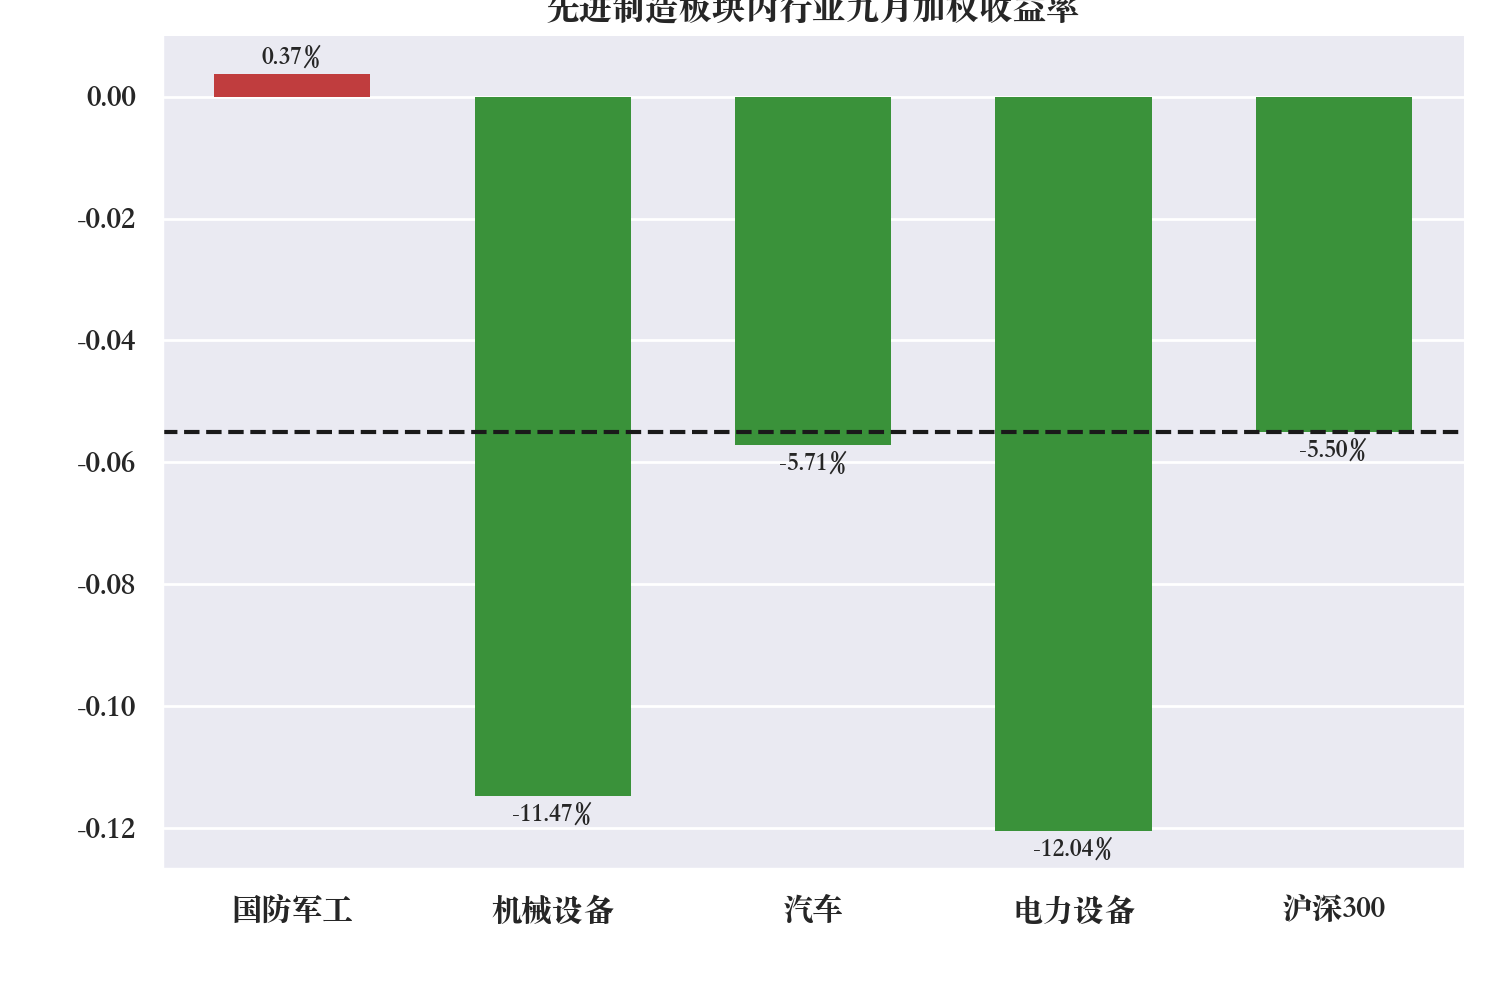

<IPython.core.display.Javascript object>


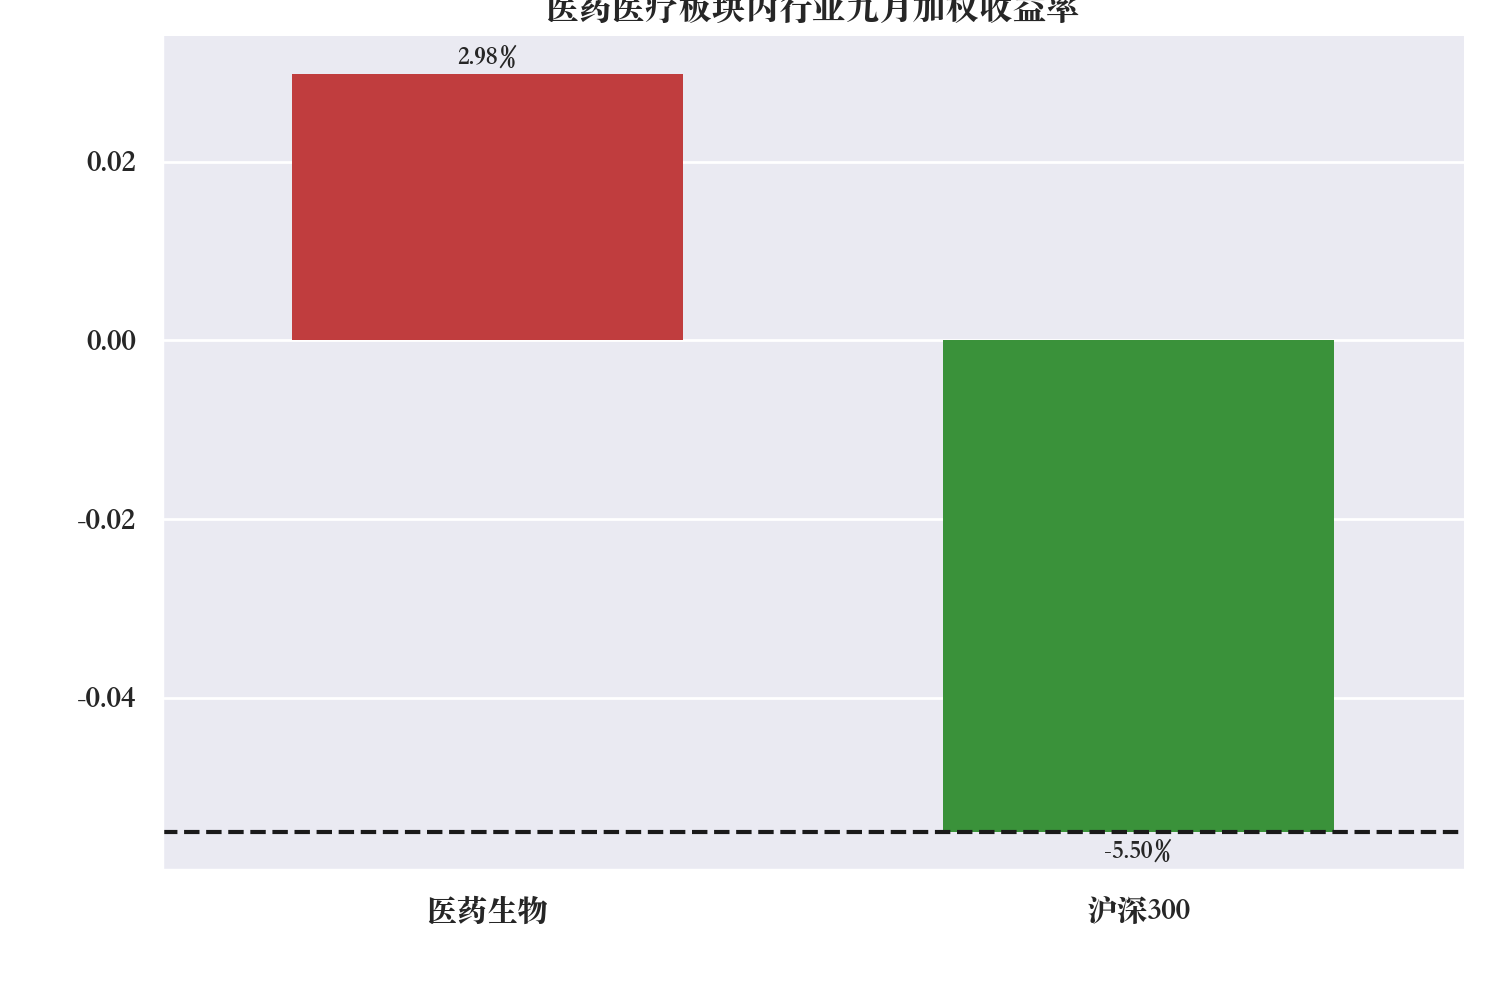

<IPython.core.display.Javascript object>


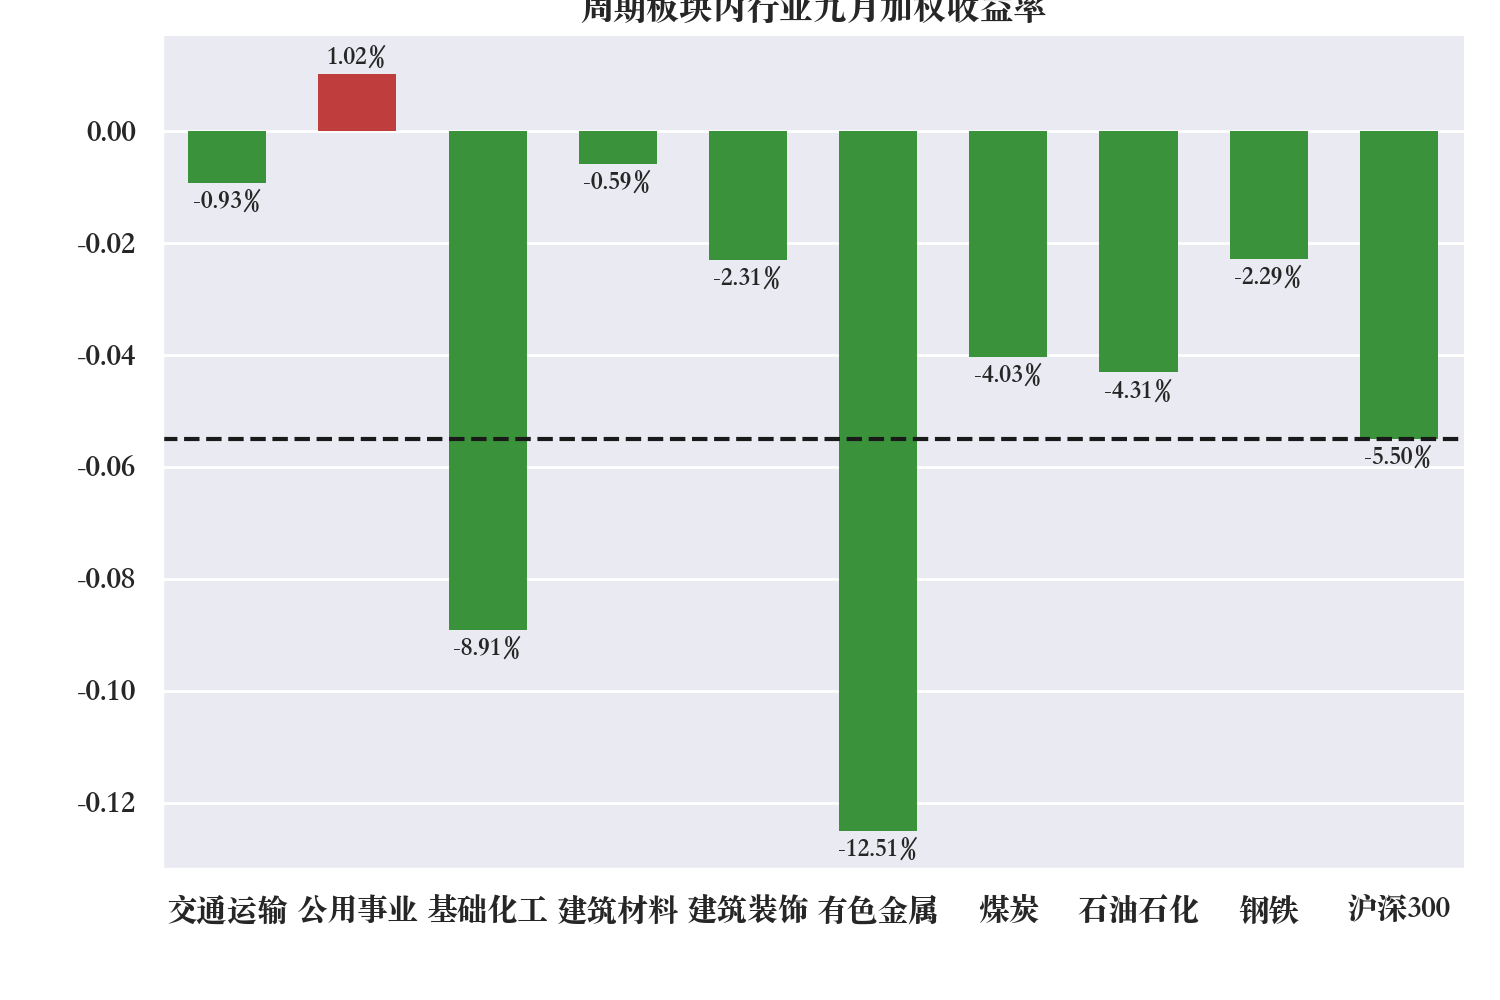

<IPython.core.display.Javascript object>


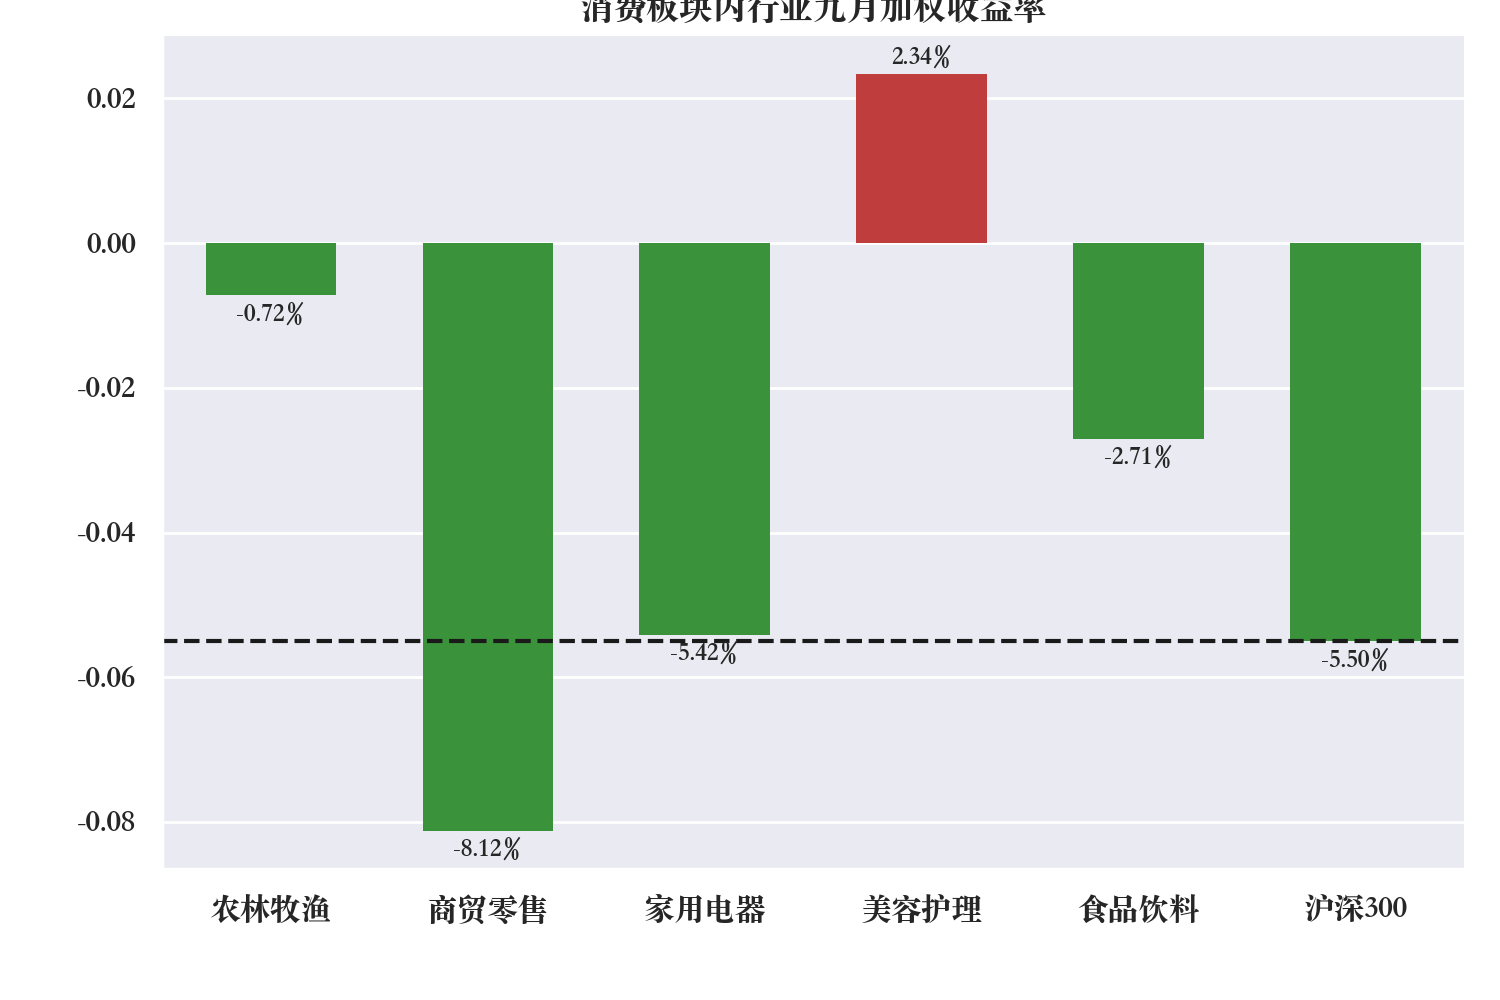

<IPython.core.display.Javascript object>


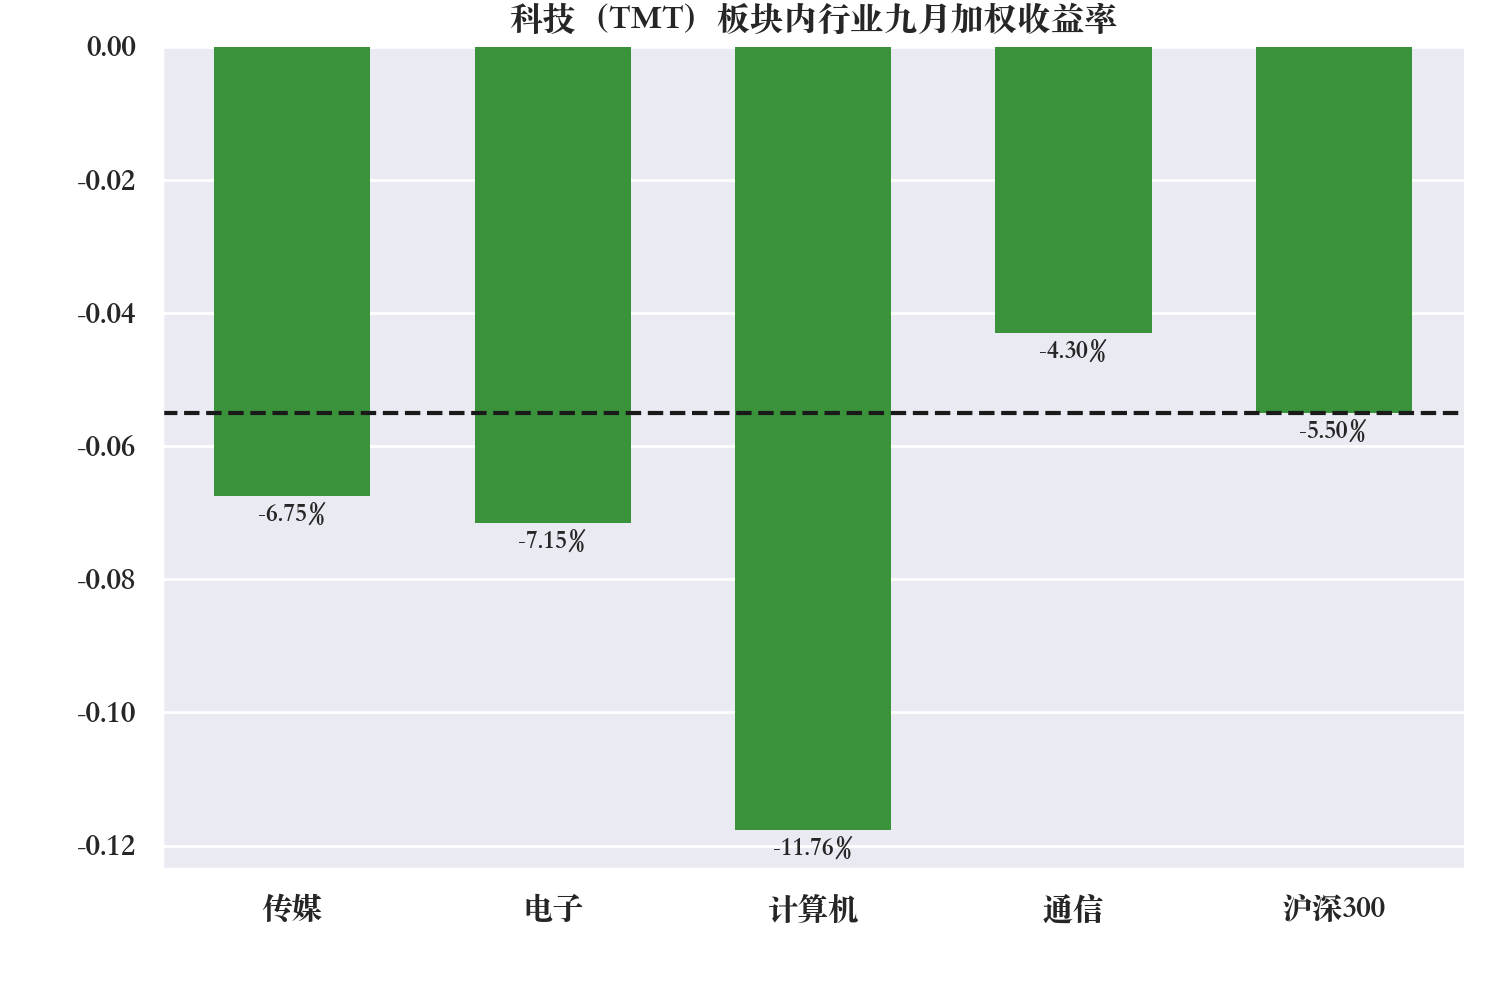

<IPython.core.display.Javascript object>


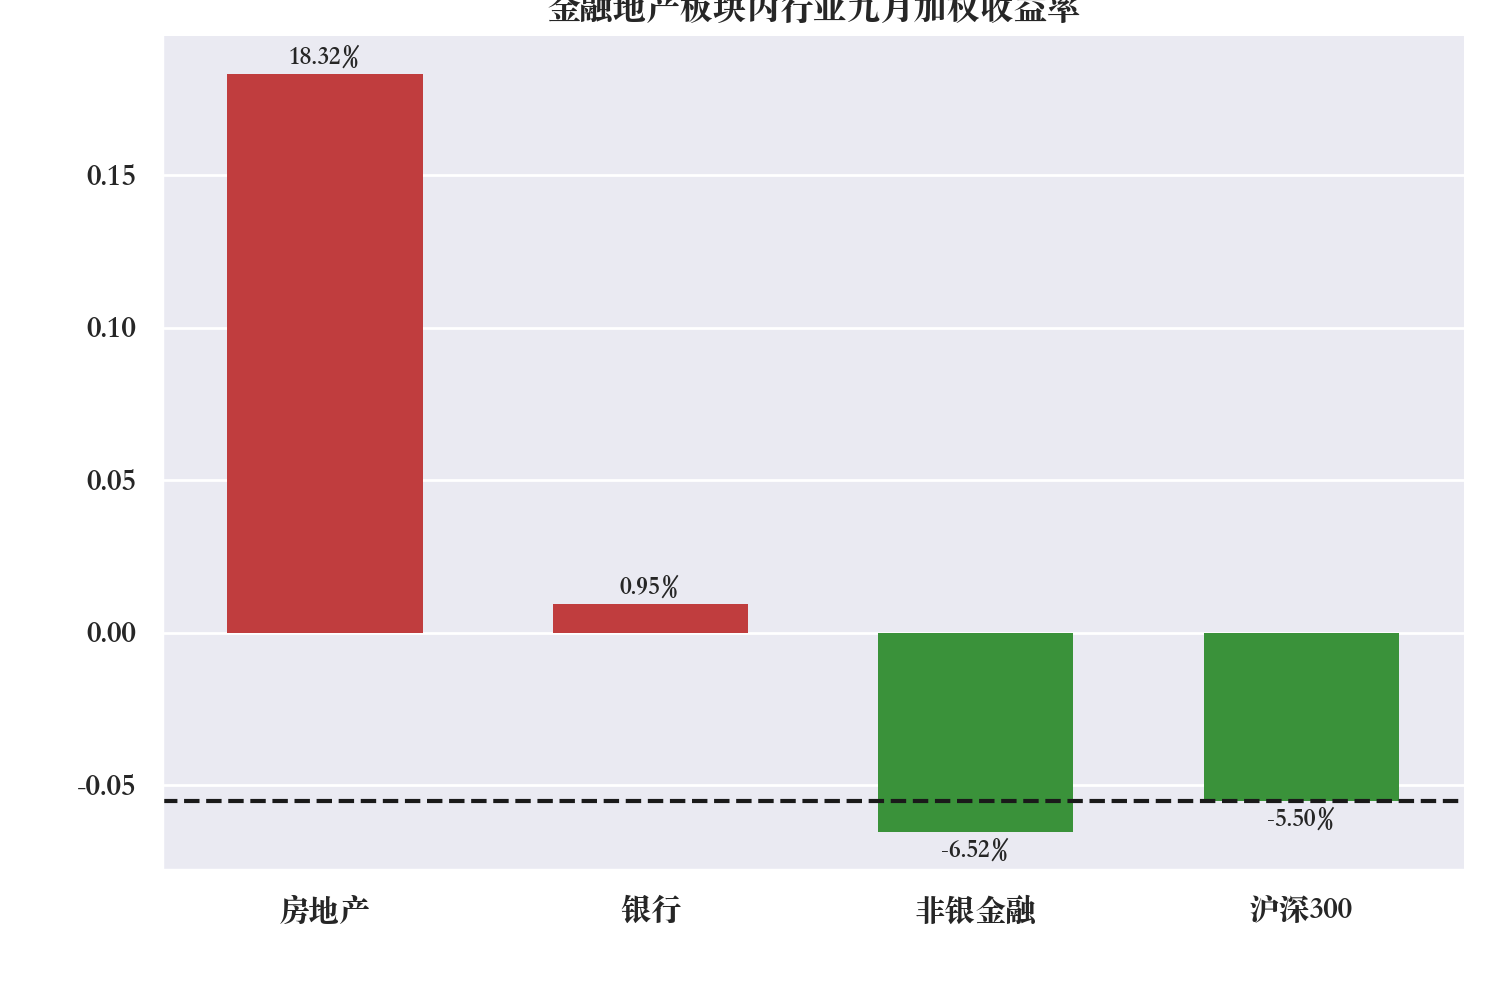

In [521]:
sns.set_theme(font='Songti SC')
plt.rcParams['axes.unicode_minus'] = False
for ret_data in ret_list:
    g = sns.catplot(data=ret_data, 
            kind='bar', 
            x='sw_industry', 
            y='ret_by_weight',
            hue='color_tag',
            palette={'正':'#d62728', '负':'#2ca02c'},
            edgecolor="none",
            width=0.6,
            aspect=1.5,
            legend=None
           )
    ax = g.ax
    ax.set(xlabel=None, ylabel=None, title=f'{ret_data["style"].iloc[0]}板块内行业九月加权收益率')
    for bar in ax.patches:
        height = bar.get_height()
        # 位置：x居中，y在柱子顶端
        x_pos = bar.get_x() + bar.get_width() / 2
        # 正负值微调文字偏移方向，防止文字贴柱子
        yshift = 2 if height > 0 else -2
        ax.annotate(
            f'{height:.2%}',
            xy=(x_pos, height),
            xytext=(0, yshift), 
            textcoords="offset points",
            ha='center', va='bottom' if height>0 else 'top',
            fontsize=9
            )
    y_hline = ret_data[(ret_data['sw_industry']=='沪深300')]['ret_by_weight'].iloc[0] 
    plt.axhline(y_hline, color='k', linestyle="--")
    g.savefig(f'desktop/stock_data/{ret_data["style"].iloc[0]}.svg', bbox_inches='tight')
    g.savefig(f'desktop/stock_data/{ret_data["style"].iloc[0]}.png', bbox_inches='tight')

In [522]:
hs300_industry = pd.read_csv('desktop/stock_data/hs300_industry.csv')

In [523]:
hs300_industry.head()

,code,name,sw_industry,sw_code
0,sh.600000,浦发银行,银行,480101
1,sh.600009,上海机场,交通运输,421002
2,sh.600010,包钢股份,钢铁,230402
3,sh.600011,华能国际,公用事业,410101
4,sh.600015,华夏银行,银行,480301


In [1]:
hs300_industry[(hs300_industry['sw_industry']=='房地产')]

NameError: name 'hs300_industry' is not defined

In [6]:
hs300_ret = pd.read_csv('desktop/stock_data/hs300_ret_202609.csv')
hs300_ret = hs300_ret.drop(columns='Unnamed: 0')
hs300_ret.head()

,code,name,sw_industry,style,weight,ret
0,sh.600000,浦发银行,银行,金融地产,0.465,0.013904
1,sh.600009,上海机场,交通运输,周期,0.110,-0.026417
2,sh.600010,包钢股份,钢铁,周期,0.194,-0.079295
3,sh.600011,华能国际,公用事业,周期,0.112,0.035294
4,sh.600015,华夏银行,银行,金融地产,0.151,-0.007911


In [7]:
hs300_ret = hs300_ret[['code', 'name', 'ret']]
hs300_ret.head()

,code,name,ret
0,sh.600000,浦发银行,0.013904
1,sh.600009,上海机场,-0.026417
2,sh.600010,包钢股份,-0.079295
3,sh.600011,华能国际,0.035294
4,sh.600015,华夏银行,-0.007911


In [13]:
hs300_ret = hs300_ret.sort_values('ret', ascending=False).reset_index

In [17]:
hs300_ret = hs300_ret.drop(columns='index')

In [19]:
hs300_ret.head()

,code,name,ret
0,sz.000002,万科A,0.348101
1,sh.600048,保利发展,0.177551
2,sz.001979,招商蛇口,0.175194
3,sh.600150,中国船舶,0.135638
4,sh.601238,广汽集团,0.114504


In [20]:
hs300_ret[:10]

,code,name,ret
0,sz.000002,万科A,0.348101
1,sh.600048,保利发展,0.177551
2,sz.001979,招商蛇口,0.175194
3,sh.600150,中国船舶,0.135638
4,sh.601238,广汽集团,0.114504
5,sz.002074,国轩高科,0.106527
6,sh.601872,招商轮船,0.095704
7,sh.600886,国投电力,0.094828
8,sh.603259,药明康德,0.087349
9,sh.600026,中远海能,0.078133


In [30]:
from matplotlib.ticker import PercentFormatter

<IPython.core.display.Javascript object>


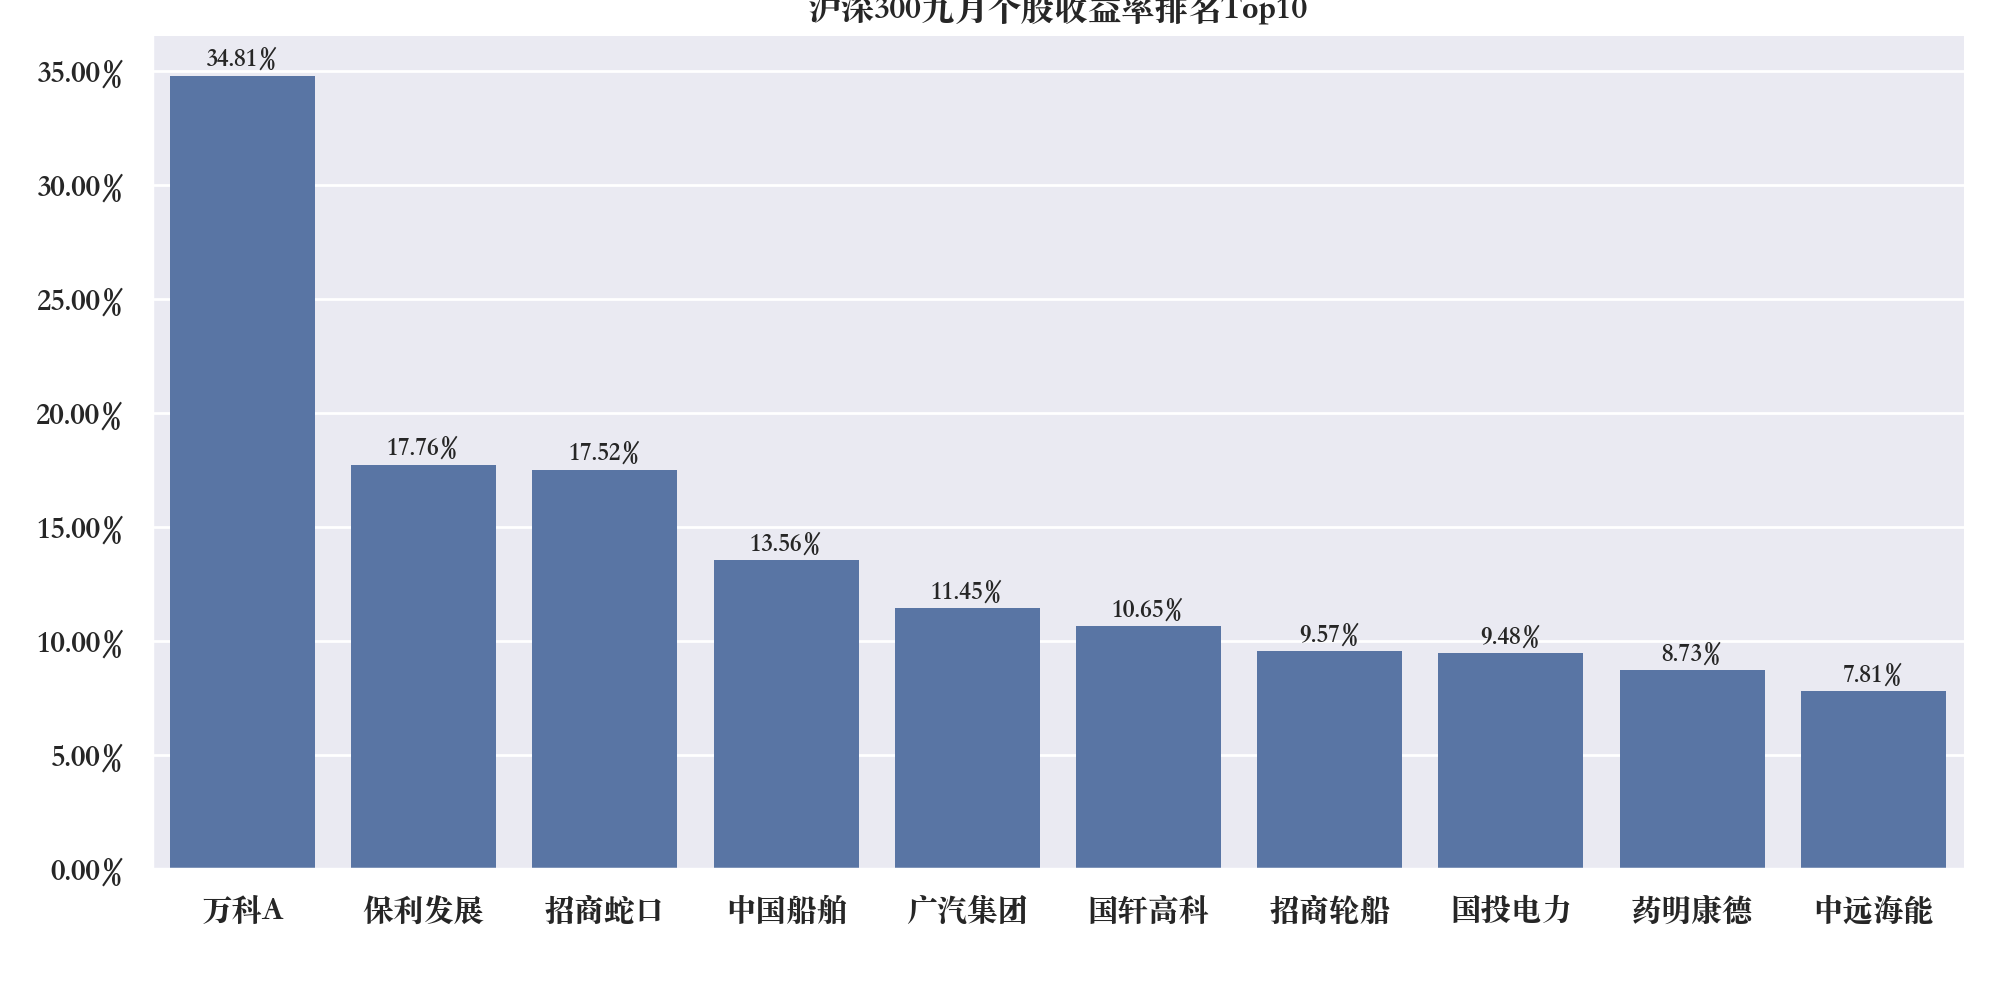

In [34]:
sns.set_theme(font='Songti SC')
plt.rcParams['axes.unicode_minus'] = False
g = sns.catplot(data=hs300_ret[:10],
            kind='bar', 
            x='name', 
            y='ret',
            edgecolor="none",
            aspect=2,
            legend=None
           )
ax = g.ax
ax.set(xlabel=None, ylabel=None, title='沪深300九月个股收益率排名Top10')
for bar in ax.patches:
    height = bar.get_height()
    # 位置：x居中，y在柱子顶端
    x_pos = bar.get_x() + bar.get_width() / 2
    # 正负值微调文字偏移方向，防止文字贴柱子
    yshift = 2 if height > 0 else -2
    ax.annotate(
        f'{height:.2%}',
        xy=(x_pos, height),
        xytext=(0, yshift), 
        textcoords="offset points",
        ha='center', va='bottom' if height>0 else 'top',
        fontsize=9
    )
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=2));


In [35]:
g.savefig('desktop/stock_data/stock_ret202609.svg', bbox_inches='tight')

In [36]:
g.savefig('desktop/stock_data/stock_ret202609.png', bbox_inches='tight')

In [38]:
hs300_data_2026 = pd.read_csv('desktop/stock_data/hs300_data_202609.csv')
hs300_data_2026.head()

,date,code,close
0,2026-09-01,sh.600000,9.35
1,2026-09-02,sh.600000,9.28
2,2026-09-03,sh.600000,9.27
3,2026-09-04,sh.600000,9.43
4,2026-09-07,sh.600000,9.23


In [40]:
hs300_code_name = pd.read_csv('desktop/stock_data/hs300_code_name.csv')
hs300_code_name = hs300_code_name[['code', 'code_name']]
hs300_code_name.head()

,code,code_name
0,sh.600000,浦发银行
1,sh.600009,上海机场
2,sh.600010,包钢股份
3,sh.600011,华能国际
4,sh.600015,华夏银行


In [41]:
hs300_data_2026 = pd.merge(hs300_data_2026, hs300_code_name)
hs300_data_2026.head()

,date,code,close,code_name
0,2026-09-01,sh.600000,9.35,浦发银行
1,2026-09-02,sh.600000,9.28,浦发银行
2,2026-09-03,sh.600000,9.27,浦发银行
3,2026-09-04,sh.600000,9.43,浦发银行
4,2026-09-07,sh.600000,9.23,浦发银行


In [43]:
hs300_data_2026['date'] = pd.to_datetime(hs300_data_2026['date'])

In [46]:
hs300_data_2026 = hs300_data_2026.set_index('date')

In [47]:
hs300_data_2026.head()

,code,close,code_name
date,,,
2026-09-01,sh.600000,9.35,浦发银行
2026-09-02,sh.600000,9.28,浦发银行
2026-09-03,sh.600000,9.27,浦发银行
2026-09-04,sh.600000,9.43,浦发银行
2026-09-07,sh.600000,9.23,浦发银行


In [48]:
df_list = []
for code in hs300_data_2026['code'].unique():
    df = hs300_data_2026[(hs300_data_2026['code']==code)]
    df_list.append(df)

In [50]:
len(df_list)

300

In [58]:
def max_drawdown(s):
    """
    s:pd.Series, 价格或净值，index为日期
    返回：最大回撤（负数）、高点日期、低点日期
    """
    running_max = s['close'].cummax()
    drawdown = s['close']/running_max - 1
    mdd = drawdown.min()
    return mdd

mdd_data = pd.DataFrame(
    hs300_data_2026.groupby('code').apply(max_drawdown, include_groups=False).sort_values(ascending=True)[:10]
    )

In [61]:
mdd_data = mdd_data.reset_index().rename(columns={0:'最大回撤'})
mdd_data

,code,最大回撤
0,sh.600547,-0.309763
1,sz.300413,-0.242986
2,sz.000977,-0.236479
3,sz.002837,-0.212294
4,sz.002625,-0.208524
5,sh.688183,-0.202889
6,sz.002460,-0.202361
7,sz.002466,-0.199309
8,sz.300750,-0.199106
9,sh.600489,-0.190807


In [62]:
hs300_code_name.head()

,code,code_name
0,sh.600000,浦发银行
1,sh.600009,上海机场
2,sh.600010,包钢股份
3,sh.600011,华能国际
4,sh.600015,华夏银行


In [63]:
mdd_data = pd.merge(mdd_data, hs300_code_name)
mdd_data

,code,最大回撤,code_name
0,sh.600547,-0.309763,山东黄金
1,sz.300413,-0.242986,芒果超媒
2,sz.000977,-0.236479,浪潮信息
3,sz.002837,-0.212294,英维克
4,sz.002625,-0.208524,光启技术
5,sh.688183,-0.202889,生益电子
6,sz.002460,-0.202361,赣锋锂业
7,sz.002466,-0.199309,天齐锂业
8,sz.300750,-0.199106,宁德时代
9,sh.600489,-0.190807,中金黄金


<IPython.core.display.Javascript object>


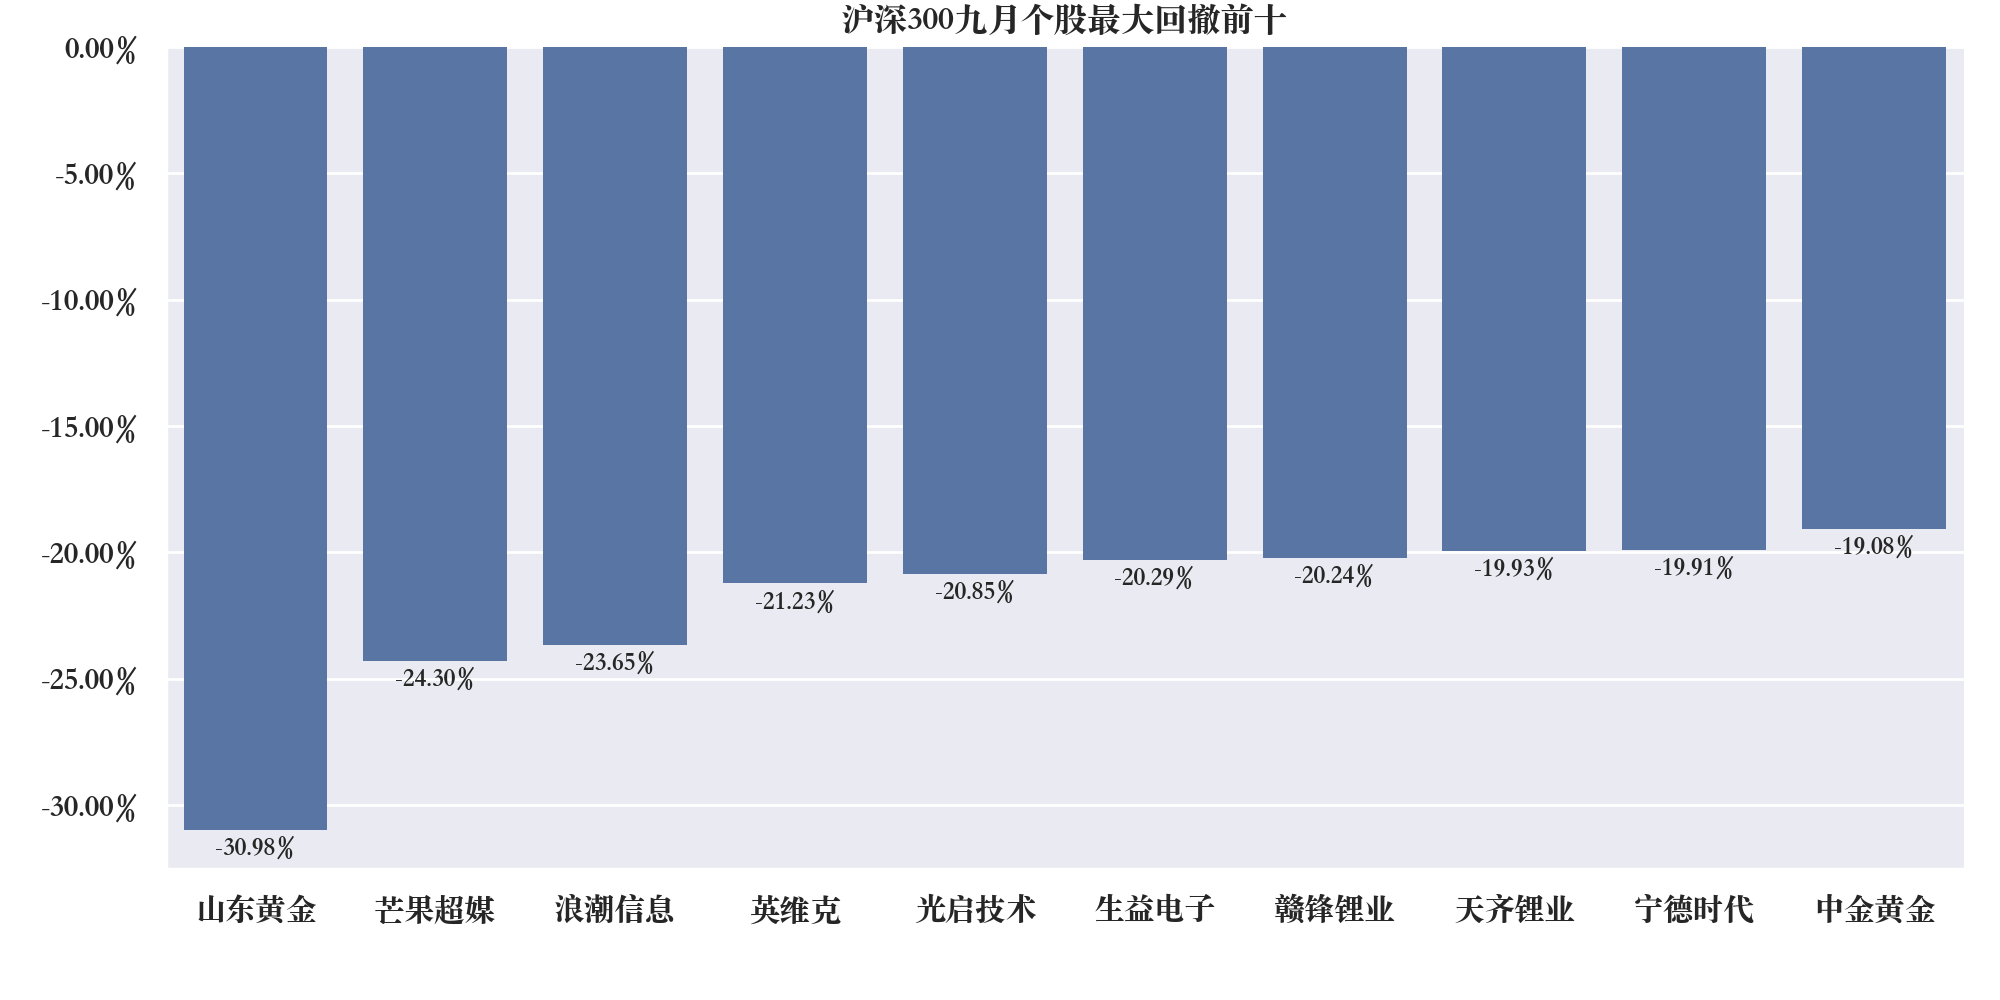

In [66]:
sns.set_theme(font='Songti SC')
plt.rcParams['axes.unicode_minus'] = False
g = sns.catplot(data=mdd_data,
            kind='bar', 
            x='code_name', 
            y='最大回撤',
            edgecolor="none",
            aspect=2,
            legend=None
           )
ax = g.ax
ax.set(xlabel=None, ylabel=None, title='沪深300九月个股最大回撤前十')
for bar in ax.patches:
    height = bar.get_height()
    # 位置：x居中，y在柱子顶端
    x_pos = bar.get_x() + bar.get_width() / 2
    # 正负值微调文字偏移方向，防止文字贴柱子
    yshift = 2 if height > 0 else -2
    ax.annotate(
        f'{height:.2%}',
        xy=(x_pos, height),
        xytext=(0, yshift), 
        textcoords="offset points",
        ha='center', va='bottom' if height>0 else 'top',
        fontsize=9
    )
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=2));

In [67]:
g.savefig('desktop/stock_data/mdd_202609.svg', bbox_inches='tight')
g.savefig('desktop/stock_data/mdd_202609.png', bbox_inches='tight')